# Datos abiertos de Airbnb en la ciudad de New York

Autores:
    - Santiago López Aristizábal
    - Arnoll Mauricio Florez Perez

Objetivo: Tomar un dataset público de Airbnb y crear un modelo capaz de predecir los precios de los inmuebles inscritos a la aplicación en la ciudad de New York 

Dataset: Contiene la información abierta de los alojamientos de Airbnb en la ciudad de New York. Se puede descargar en https://insideairbnb.com/get-the-data/ y el diccionario de la data en https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596 donde se tomo la última versión de listings.csv.

Resumen general del proceso realizado:
1. Obtener la data.
2. Preparación de la data:
    - Eliminación de columnas sin relevancia para el precio de los alojamientos.
    - Busquedad de duplicados.
    - Eliminación de datos pre-pandemia.
    - Reformateo de columnas.
    - Imputación de datos faltantes.
    - Creación de característica de distancia mínima a lugares turísticos.
    - Creación de características con base en las comodidades de los alojamientos:
        * Clusterización con base en modelo de sentence-transformers (https://huggingface.co/sentence-transformers/all-MiniLM-L12-v2).
    - Limpieza de outliers en variable objetivo e independientes.
3. Entrenamiento de modelos:
    - Elección de modelos de regresión:
        * Multi Layer Perceptron (MLP) sin tener en cuenta las comodidades, solo datos estructurales  del alojamiento, ubicación y reseña.
        * Multi Layer Perceptron (MLP) tomando como base la clusterización de las comodidades para crear variables booleanas.
        * Extreme Gradient Boosting tomando como base la clusterización de las comodidades para crear variables booleanas.
    - Creación inicial de modelos
    - Afinación de modelos.
4. Comparación de modelos
    - Resultados de R² por modelo
5. Persistencia de modelos
6. Conclusiones



## 1. Librerias y configuraciones previas

In [ ]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np
import ast
import re
from collections import Counter


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math

# Preparación de datos
# ==============================================================================
from sklearn.neighbors import LocalOutlierFactor
from geopy.distance import geodesic
import umap

# Preprocesado y modelado
# ==============================================================================

# Creación y entrenamiento de modelos
import joblib
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sentence_transformers import SentenceTransformer
import hdbscan

# Escalar Variables
from sklearn.preprocessing import StandardScaler

# Evaluacion de variables
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
# Rutas
# ==============================================================================
DATASET_PATH = 'datasets/'
MODELOS_PATH = 'modelos/'

## 2. Funciones

In [3]:
def reformat_true_false_columns(df, columns):
    for col in columns:
        df[col] = df[col].fillna('f')
        df[col] = df[col].map({'t': True, 'f': False})
    return df

def reformat_price_column(df, column):
    df[column] = df[column].str.replace('$', '').str.replace(',', '').astype(float)
    return df

def normalize_amenity(a):
    a = a.lower().strip()

    # STREAMING
    streaming_pattern = r'netflix|hbo|max|disney|amazon prime video|hulu|roku|apple tv|chromecast|fire tv'
    a = re.sub(streaming_pattern, 'streaming', a)
    # NORMALIZAR TV
    a = re.sub(r'hdtv|smart tv', 'tv', a)
    # NORMALIZAR TV CABLE
    cable_pattern = r'premium cable|standard cable|cable tv'
    a = re.sub(cable_pattern, 'cable', a)
    # WIFI
    a = re.sub(r'fast wifi', 'wifi', a)

    # REFRIGERATOR - patrón ampliado con fuzzy matching por prefijo
    refrigerator_pattern = (
        r'\brefri[a-z]*\b|'   # captura refri, refrigerator, refridgerator, refrirator, etc.
        r'\bfridge\b|'
        r'\bfrid\b|'
        r'\brefrigerador\b'
    )
    if re.search(refrigerator_pattern, a):
        a = re.sub(refrigerator_pattern, 'refrigerator', a)  # reemplazar en lugar de eliminar y añadir al final

    # ELIMINAR NÚMEROS
    a = re.sub(r'\d+', '', a)
    # ELIMINAR UNIDADES
    a = re.sub(r'mbps|gbps|inch|inches', '', a)
    # ELIMINAR MARCAS
    brand_pattern = r'\b(samsung|bose|sonos|lg|ge|bosch|frigidaire|whirlpool|amana|smeg|insignia|keurig|kitchenaid|magic chef)\b'
    a = re.sub(brand_pattern, '', a)
    # ELIMINAR STOPWORDS
    stop_words_pattern = r'\b(available|upon request|specific hours|extra cost|days a week|every day|hours|day|week|yes|only|when|asked|can|use|new|brand|small|mini|for|the|in|room|minimal|stora)\b'
    a = re.sub(stop_words_pattern, '', a)
    # ELIMINAR "with"
    a = re.sub(r'\bwith\b', '', a)
    # ELIMINAR SÍMBOLOS
    a = re.sub(r'[^a-z\s]', '', a)
    # ELIMINAR STREAMING REPETIDO
    a = re.sub(r'(streaming\s*)+', 'streaming ', a)
    # ELIMINAR CABLE REPETIDO
    a = re.sub(r'(cable\s*)+', 'cable ', a)
    # ELIMINAR REFRIGERATOR REPETIDO
    a = re.sub(r'(refrigerator\s*)+', 'refrigerator ', a)
    # COLAPSAR ESPACIOS
    a = re.sub(r'\s+', ' ', a).strip()
    # ELIMINAR PALABRAS DUPLICADAS
    words = list(dict.fromkeys(a.split()))
    return ' '.join(words)


def format_amenities_to_text(text: str) -> str:
    text = text.replace("[", "").replace("]", "")  # Limpiar corchetes
    text = text.replace("'", "").replace('"', "")  # Limpiar comillas
    text = text.strip().strip(",")                 # Separar por comas
    # Convierte a oración natural con prefijo
    return "This place offers: " + text

def map_amenities(lst):
    mapped = set()
    for amenity in lst:
        for label, pattern in patterns.items():
            if re.search(pattern, amenity):
                mapped.add(label)
    return list(mapped)


def crear_modelo_mlp(input_shape):
    model = Sequential([
        Dense(32, activation="relu", input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dropout(0.3),
        Dense(8, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def entrenar_modelo( X_train, y_train, model, nombre_modelo):
    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    history_mlp = model.fit(
                                X_train,
                                y_train,
                                validation_split=0.15,
                                epochs=50,
                                batch_size=32,
                                callbacks=[early_stop],
                                verbose=2
                                )
    print(f"{nombre_modelo} entrenado.")

    plt.plot(history_mlp.history["loss"])
    plt.plot(history_mlp.history["val_loss"])
    plt.title("Model Loss - " + nombre_modelo)
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"])
    plt.show()

    return history_mlp

def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred_log = modelo.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_real = np.expm1(y_test)
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    print(f"{nombre_modelo} - R²: {r2:.4f}, MAE: {mae:.4f}, MSE: {mse:.4f}")
    return r2, mae, mse

In [4]:
# Sitios turísticos en New York City con sus coordenadas (latitud, longitud)
sitios_turisticos = {
    'statue_of_liberty': (40.6892, -74.0445),
    'central_park': (40.785091, -73.968285),
    'empire_state': (40.748817, -73.985428),
    'museo_metropolitano_de_arte_(met)': (40.7794, -73.9632),
    'time_square': (40.7580, -73.9855),
    'brooklyn_bridge': (40.7061, -73.9969),
    'vessel': (40.7532, -74.0020),
    'september_11_memorial': (40.7115, -74.0134),
    'madison_square_garden': (40.7505, -73.9934),
    'rockefeller_center': (40.7587, -73.9787),
    'museo_americano_historia_natural': (40.7813, -73.9735),
}

def distancia_minima_turistica(lat, lon):
    """Calcula la distancia mínima (en km) desde una coordenada a los sitios turísticos de NYC."""
    distancias = [
        geodesic((lat, lon), coords).km
        for coords in sitios_turisticos.values()
    ]
    return min(distancias)

In [5]:
# Funciones externas
# ==============================================================================

from utils.funciones import multiple_plot

## 3. Carga del dataset

In [6]:
#Cargar el dataset
data = pd.read_csv(DATASET_PATH +'listings.csv')

## 4. Limpieza de datos (Data Cleaning)

In [7]:
#Borrando columnas que no se utilizarán
data.drop(['listing_url','scrape_id','last_scraped','source','name','description','neighborhood_overview','picture_url','host_url','host_name','host_since','host_location','host_about','host_response_time','host_response_rate','host_acceptance_rate','host_is_superhost','host_thumbnail_url','host_picture_url','host_neighbourhood','host_listings_count','host_total_listings_count','host_verifications','host_has_profile_pic','host_identity_verified','neighbourhood','neighbourhood_cleansed','neighbourhood_group_cleansed','property_type','minimum_nights','maximum_nights','minimum_minimum_nights','maximum_minimum_nights','minimum_maximum_nights','maximum_maximum_nights','minimum_nights_avg_ntm','maximum_nights_avg_ntm','calendar_updated','has_availability','availability_30','availability_60','availability_90','availability_365','calendar_last_scraped','number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d','availability_eoy','number_of_reviews_ly','estimated_occupancy_l365d','estimated_revenue_l365d','first_review','calculated_host_listings_count','calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms','reviews_per_month','review_scores_rating','review_scores_accuracy','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location'], axis='columns', inplace=True)


Vamos a revisar si hay registros duplicados

In [8]:
datos_duplicados = data.duplicated()
print(f"Número de filas duplicadas: {datos_duplicados.sum()}")

Número de filas duplicadas: 0


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 36403 entries, 0 to 36402
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   36403 non-null  int64  
 1   host_id              36403 non-null  int64  
 2   latitude             36403 non-null  float64
 3   longitude            36403 non-null  float64
 4   room_type            36403 non-null  str    
 5   accommodates         36403 non-null  int64  
 6   bathrooms            21546 non-null  float64
 7   bathrooms_text       36276 non-null  str    
 8   bedrooms             30483 non-null  float64
 9   beds                 21495 non-null  float64
 10  amenities            36403 non-null  str    
 11  price                21279 non-null  str    
 12  last_review          25093 non-null  str    
 13  review_scores_value  25056 non-null  float64
 14  license              5466 non-null   str    
 15  instant_bookable     36403 non-null  str    
dt

La columna "license" es la que mayor cantidad de valores nulos presenta, así que vamos a analizarla

In [10]:
data['license'].unique()

<StringArray>
[                 nan, 'OSE-STRREG-0000008', 'OSE-STRREG-0001970',
 'OSE-STRREG-0001150', 'OSE-STRREG-0000108', 'OSE-STRREG-0001710',
             'Exempt', 'OSE-STRREG-0000041', 'OSE-STRREG-0000832',
 'OSE-STRREG-0001784',
 ...
 'OSE-STRREG-0003141', 'OSE-STRREG-0003088', 'OSE-STRREG-0003148',
 'OSE-STRREG-0003182', 'OSE-STRREG-0001929', 'OSE-STRREG-0003180',
 'OSE-STRREG-0002772', 'OSE-STRREG-0003191', 'OSE-STRREG-0003196',
 'OSE-STRREG-0001043']
Length: 1979, dtype: str

Vemos que la mayoría de los registros inician con "OSE-STRREG", esto hace referencia al OSE Short Term Rental Registration de la ciudad de New York. Así que revisemos los que no contenga ese string en la licencia.

In [11]:
data[~data['license'].str.upper().str.contains('OSE-STRREG', na=False)]['license'].unique()

<StringArray>
[nan, 'Exempt']
Length: 2, dtype: str

Lo que se observa de la columna "license", es que se tienen alojamientos licenciados, otros exentos y el resto sin licencia, así que se trabajará como una variable booleana, agrupando los licenciados con los exentos.

In [12]:
data['license'] = (
    data['license'].str.upper().str.contains('OSE-STRREG', na=False)
    | data['license'].str.contains('Exempt', na=False)
)


Ahora se convertira la columna "last_review" a un tipo de dato datetime para facilitar su manipulación

In [13]:
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')

Se crea una nueva columna con el año de la última reseña y el año de inscripción del host en Airbnb

In [14]:
data['year_last_review'] = data['last_review'].dt.year.astype('Int64')

# Se borra la columna con las fecha completa
data.drop(['last_review'], axis='columns', inplace=True)

Ahora analicemos esta nueva columna

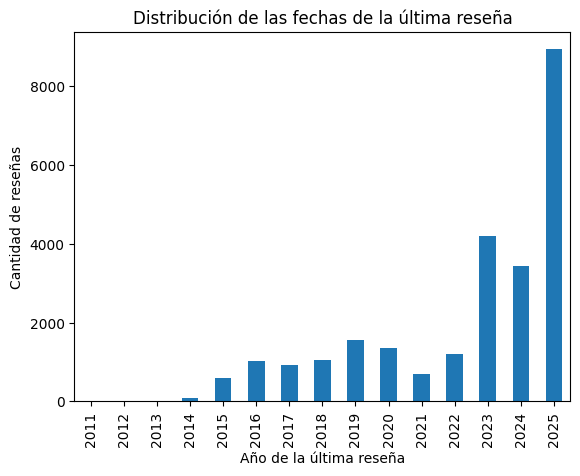

In [15]:
data['year_last_review'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de las fechas de la última reseña')
plt.xlabel('Año de la última reseña')
plt.ylabel('Cantidad de reseñas')
plt.show()

Se tienen alojamientos cuya última reseña fue hace más de 10 años y es probable que ya no estén en funcionamiento, esto puede distorsionar el análisis de la oferta de alojamientos actualmente, ya que aunque para los huéspedes no sea obligatorio realizar una reseña de los alojamientos, que no se tengan reseñas en tanto tiempo es poco probable, adicionalmente tomando en cuenta la pandemia del COVID-19 durante su apogeo en el 2020 se presento una caída drástica en las reservas por las diferentes medidas de cuarentena implementadas por los gobiernos, es decir que fue un año muy atípico para el turismo a nivel mundial y posiblemente muchos de los alojamientos tuvieron que cerrar, incluso de la tabla anterior se observa que hay una disminución en la cantidad de reseñas, por este motivo se dropearan los registros anteriores al 2022 para tener la data más reciente.

In [16]:
data.drop(data[data['year_last_review'] < 2022].index, inplace=True)

Eliminamos la columna que ya no será necesaria

In [17]:
data.drop(['year_last_review'], axis='columns', inplace=True)

Reformateamos las columnas categoricas

In [18]:
data_formatted = data.copy()
data_formatted = reformat_true_false_columns(data_formatted, ['instant_bookable'])
data_formatted = reformat_price_column(data_formatted, 'price')

Como vamos a predecir el precio de los alojamientos debemos dropear los alojamientos sin precio

In [19]:
# Dropear registros sin precio
data_formatted.dropna(subset=['price'], inplace=True)

In [20]:
# Reorganizamos el dataframe para que la variable objetivo esté en la primera columna
cols = data_formatted.columns.tolist()
cols.insert(0, cols.pop(cols.index('price')))
data_formatted = data_formatted[cols]

También eliminamos los registros que no tienen puntuaciones en las reseñas 

In [21]:
data_formatted = data_formatted[data_formatted['review_scores_value'].notna()]
data_formatted.reset_index(drop=True, inplace=True)

In [22]:
data_formatted.info()

<class 'pandas.DataFrame'>
RangeIndex: 14019 entries, 0 to 14018
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                14019 non-null  float64
 1   id                   14019 non-null  int64  
 2   host_id              14019 non-null  int64  
 3   latitude             14019 non-null  float64
 4   longitude            14019 non-null  float64
 5   room_type            14019 non-null  str    
 6   accommodates         14019 non-null  int64  
 7   bathrooms            14015 non-null  float64
 8   bathrooms_text       14008 non-null  str    
 9   bedrooms             13985 non-null  float64
 10  beds                 13990 non-null  float64
 11  amenities            14019 non-null  str    
 12  review_scores_value  14019 non-null  float64
 13  license              14019 non-null  bool   
 14  instant_bookable     14019 non-null  bool   
dtypes: bool(2), float64(7), int64(3), str(3)
memory

Segun esto tenemos varios registros que no tienen baños, ni camas, ni habitaciones.

Evaluemos los registros a los que le falta la cantidad de baños

In [23]:
data_formatted[data_formatted['bathrooms'].isnull()][['bathrooms_text', 'bathrooms']].head()

,bathrooms_text,bathrooms
166,NaN,NaN
11144,NaN,NaN
13343,NaN,NaN
13893,NaN,NaN


Como no podemos asignarles el valor desde el 'bathrooms_text', los dropeamos y también esa columna

In [24]:
data_formatted = data_formatted[data_formatted['bathrooms'].notna()]
data_formatted.drop(columns=['bathrooms_text'], inplace=True)
data_formatted.reset_index(drop=True, inplace=True)

Ahora revisemos que sucede con la columna 'beds'

<Axes: xlabel='beds'>

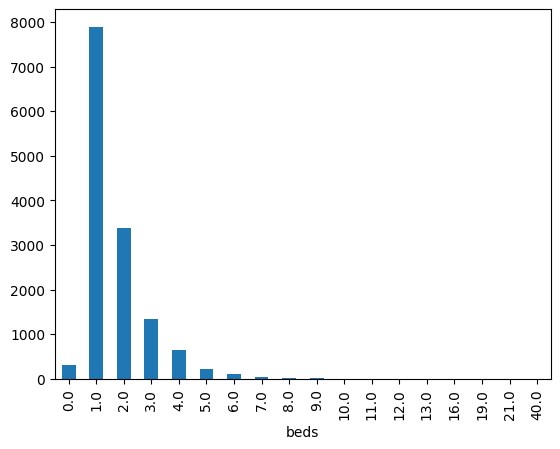

In [25]:
data_formatted['beds'].value_counts().sort_index().plot(kind='bar')

In [26]:
# Imputar valores faltantes de 'beds' con la moda según 'room_type'
data_formatted['beds'] = data_formatted['beds'].fillna(
    data_formatted.groupby('room_type')['beds']
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [27]:
# Reemplazar valores 0 en 'beds' con el valor entero de la división entre 'accommodates' y 2
data_formatted['beds'] = data_formatted.apply(
    lambda row: max(1, row['accommodates'] // 2) if row['beds'] == 0 else row['beds'], axis=1
)

Ahora revisemos que sucede con la columna 'bedrooms'

<Axes: xlabel='bedrooms'>

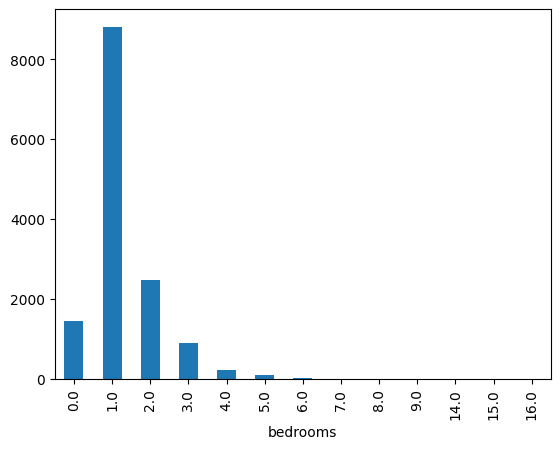

In [28]:
data_formatted['bedrooms'].value_counts().sort_index().plot(kind='bar')

In [29]:
# Imputar valores faltantes de 'bedrooms' con la moda según 'room_type'
data_formatted['bedrooms'] = data_formatted['bedrooms'].fillna(
    data_formatted.groupby('room_type')['bedrooms']
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [30]:
# Como no tenemos registros duplicados y ya se realizó la limpieza del dataset podemos proceder a dropear las columnas de id y host_id
data_formatted.drop(['id','host_id'], axis='columns', inplace=True)

In [31]:
data_formatted.info()

<class 'pandas.DataFrame'>
RangeIndex: 14015 entries, 0 to 14014
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                14015 non-null  float64
 1   latitude             14015 non-null  float64
 2   longitude            14015 non-null  float64
 3   room_type            14015 non-null  str    
 4   accommodates         14015 non-null  int64  
 5   bathrooms            14015 non-null  float64
 6   bedrooms             14015 non-null  float64
 7   beds                 14015 non-null  float64
 8   amenities            14015 non-null  str    
 9   review_scores_value  14015 non-null  float64
 10  license              14015 non-null  bool   
 11  instant_bookable     14015 non-null  bool   
dtypes: bool(2), float64(7), int64(1), str(2)
memory usage: 1.1 MB


Vamos a crear una nueva variable que nos indique la distancia mínima en kilometros a alguno de los sitios turisticos de New York City, ya que esto generalmente resulta relevante a la hora de definir los precios para un alojamiento

In [32]:
data_formatted["distance_min"] = data_formatted.apply(lambda row: distancia_minima_turistica(row["latitude"], row["longitude"]), axis=1)

Ahora vamos a procesar las comodidades de los alojamientos

In [33]:
# Normalizamos las comodidades, quitamos símbolos, dejamos todo en minusculas y algunas normalizaciones
data = data_formatted.copy()

data['amenities'] = data['amenities'].apply(ast.literal_eval)

data['amenities'] = data['amenities'].apply(
    lambda lst: list(
        dict.fromkeys(   # elimina duplicados manteniendo orden
            normalize_amenity(x)
            for x in lst
        )
    )
)

In [34]:
# Guardamos el dataset limpio antes de transformar las comodidades a texto
data.to_csv(DATASET_PATH + 'airbnb_ny_raw.csv', index=False)

Ahora vamos a realizar la clusterización de las comodidades individualmente usando un sentence-transformer que nos mapea las oraciones a un vector de 384 dimensiones, para posteriormente realizar una reducción de dimensionalidad con UMAP y finalmente la clusterización con HDBSCAN.

In [36]:
all_amenities = list(set(
    amenity
    for row in data["amenities"]
    for amenity in row
))

print(f"Total de comodidades únicas: {len(all_amenities)}")

Total de comodidades únicas: 2252


In [37]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L12-v2")

amenity_embeddings = model.encode(all_amenities, show_progress_bar=True)

print(amenity_embeddings.shape)

Batches: 100%|██████████| 71/71 [00:01<00:00, 38.78it/s]

(2252, 384)


In [38]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.05,
    n_components=15,
    random_state=42
)

X_umap = reducer.fit_transform(amenity_embeddings)

In [39]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=20)

amenity_clusters = clusterer.fit_predict(X_umap)

In [40]:
amenity_cluster_map = dict(zip(all_amenities,  amenity_clusters))

In [41]:
cluster_counts = pd.Series(amenity_clusters).value_counts().sort_index()

print(cluster_counts)

-1      32
 0     199
 1     433
 2     633
 3      44
 4      38
 5      43
 6     170
 7      40
 8     361
 9      23
 10     33
 11     25
 12    178
Name: count, dtype: int64


In [42]:
cluster_df = pd.DataFrame({
    "amenity": all_amenities,
    "cluster": amenity_clusters
})

for c in sorted(cluster_df["cluster"].unique()):
    print(f"\nCluster {c}")
    print(
        cluster_df[
            cluster_df["cluster"] == c
        ]["amenity"].head(20).tolist()
    )


Cluster -1
['split system just press orange button on thermostat and arrow adjust temp make sure mode you have icon of snow flake conditioner', 'clothing storage walk closet', 'heating split type ductless system', 'radiant heating', 'clothing storage', 'portable heater', 'clothing storage walk closet and', 'clothing storage walk closet wardrobe and dresser', 'clothing storage closet and wardrobe', 'clothing storage dresser', 'drying rack clothing', 'portable fans', 'portable air conditioning', 'central air conditioning', 'air conditioning', 'heating', 'central heating', 'clothing storage walk closet and wardrobe', 'air conditioner', 'frederick air conditioner']

Cluster 0
['tv dvd player streaming', 'audioengine bluetooth sound system', 'projector living space bluetooth sound system', 'amazon echo google nest home bluetooth sound system', 'marshall emberton bluetooth sound system', 'google bluetooth sound system', 'unknown at time of posting sound system bluetooth and aux', 'sound sys

Con base en los clusters que se crearon gracias al Sentence Transformer se definen algunas de las palabras más frecuentes que se van a encontrar en las comodidades de los alojamientos y se agrupan de la siguiente forma para crear una característica booleana para cada una de ellas, ya que cada alojamiento puede tener más de una comodidad de las clusterizadas

In [43]:
patterns = {
    'tv_and_internet' : r'wifi|internet|ethernet|\btv\b|hdtv|smart tv|flat.?screen|streaming|home theater',
    'kitchen': r'kitchen|stove|oven|microwave|refrigerator|fridge|dishwasher|coffee maker|toaster|cookware|kettle',
    'climate': r'heater|heating|radiator|furnace|air.?conditioning|\bac\b|fan',
    'luxurious' : r'pool|swim|hot tub|jacuzzi|spa|sauna|piano',
    'fitness': r'gym|fitness|exercise equipment',
    'parking': r'parking|garage|carport|free parking',
    'washer': r'washer|laundry|washing machine',
    'dryer': r'\bdryer\b(?! hair)',
    'cleaning_products': r'cleaning product|detergent|soap|shampoo|conditioner|body wash|towels|linens|bed sheets',
    'workspace': r'workspace|desk|office|laptop friendly|work desk',
    'balcony_view': r'balcony|patio|terrace|deck|garden|yard|view|sea view|mountain view|city view',
    'family': r'crib|high chair|baby bath|children|kids|toys|books for children',
    'pet_friendly': r'pet|pets allowed',
    'security': r'lock|safe|security camera|alarm system',
    'accessibility': r'wheelchair|accessible|elevator|lift',
    'outdoor': r'bbq|barbecue|grill|fire pit|outdoor furniture',
    'entertainment': r'game|console|xbox|playstation|board games|game room|sound system|stereo|speaker',
}

In [44]:
# Se agrupan las amenidades
data['amenities_grouped'] = data['amenities'].apply(map_amenities)

# Unir todas las listas en una sola
amenities_flat = [amenity for sublist in data['amenities_grouped'] for amenity in sublist]

# Contar frecuencia
counter = Counter(amenities_flat)

print("Frecuencia de amenidades agrupadas:")
for amenity, freq in counter.most_common():
    print(f"{amenity}: {freq}")

Frecuencia de amenidades agrupadas:
tv_and_internet: 13977
climate: 13906
kitchen: 13646
cleaning_products: 12142
dryer: 11767
security: 9795
parking: 9222
luxurious: 9214
workspace: 8933
washer: 7133
balcony_view: 4635
pet_friendly: 3573
accessibility: 2913
outdoor: 2619
family: 2613
fitness: 2128
entertainment: 2093


In [45]:
# Se crea una columna dummy por cada amenidad agrupada
for a,_ in counter.items():
    data[f'amenity_{a}'] = data['amenities_grouped'].apply(lambda x: a in x) # Devuelve True o False

También se creará una nueva variable con la cantidad de amenidades

In [46]:
data["amenities_count"] = data["amenities"].apply(len)

In [47]:
# Eliminar las columnas que más del 85% de los registros tienen esa amenidad y se pueden considerar esenciales
data.drop(['amenity_tv_and_internet', 'amenity_climate', 'amenity_kitchen','amenity_cleaning_products'], axis='columns', inplace=True)

In [ ]:
# Eliminar las columnas auxiliares o que ya no se utilizarán
data.drop(['amenities', 'amenities_grouped'], axis='columns', inplace=True)

## 5. Visualización de datos

### Variable de salida

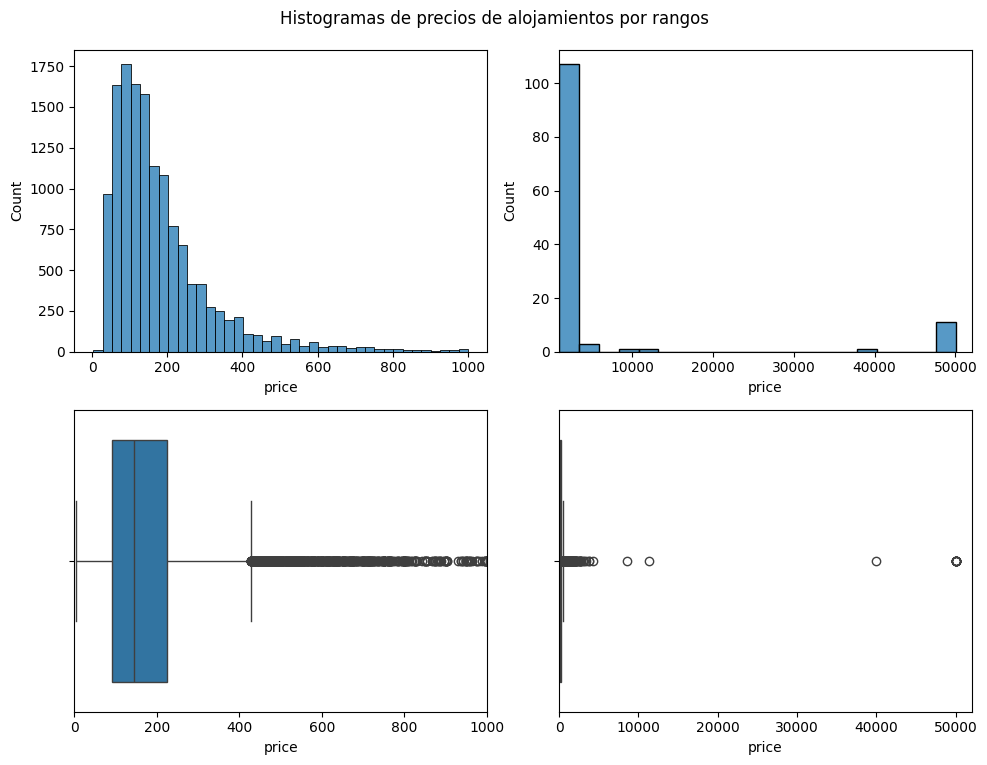

In [50]:
# Histogramas y boxplots de precios por rangos
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axs = axs.flatten()

sns.histplot(data[data['price'] <= 1000]['price'], bins=40, ax=axs[0])

sns.histplot(data[data['price'] > 1000]['price'], bins=20, ax=axs[1])
axs[1].set_xlim(1000, 52000)  # limitar escala para ver mejor

sns.boxplot(x=data['price'], ax=axs[2])
axs[2].set_xlim(0, 1000)  # limitar escala para ver mejor

sns.boxplot(x=data['price'], ax=axs[3])
axs[3].set_xlim(0, 52000)  # limitar escala para ver mejor

fig.suptitle('Histogramas de precios de alojamientos por rangos')
plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Ajustar el rectangulo para dejar espacio al suptitle
plt.show()

Calculo de valores atípicos

In [51]:
#Calculo de Q1 t Q3
Q1 = np.percentile(data['price'], 25, method = 'midpoint')
Q3 = np.percentile(data['price'], 75, method = 'midpoint')

#Cálculo del rango intercuartil
IQR = Q3 - Q1

#Cálculo de valor mínimo y máximo para los valores atípicos
VAInf = Q1 - 1.5*IQR
VASup = Q3 + 1.5*IQR

print(f'Valor atípico leve inferior:{VAInf}')
print(f'Valor atípico leve superior:{VASup}')

Valor atípico leve inferior:-112.5
Valor atípico leve superior:427.5


In [52]:
data[data['price']>VASup].shape

(902, 26)

In [53]:
# Se eliminan los valores atípicos de la variable objetivo
data = data.drop(data[data['price']>VASup].index)

#Reiniciar el indice
data.reset_index(drop=True, inplace=True)

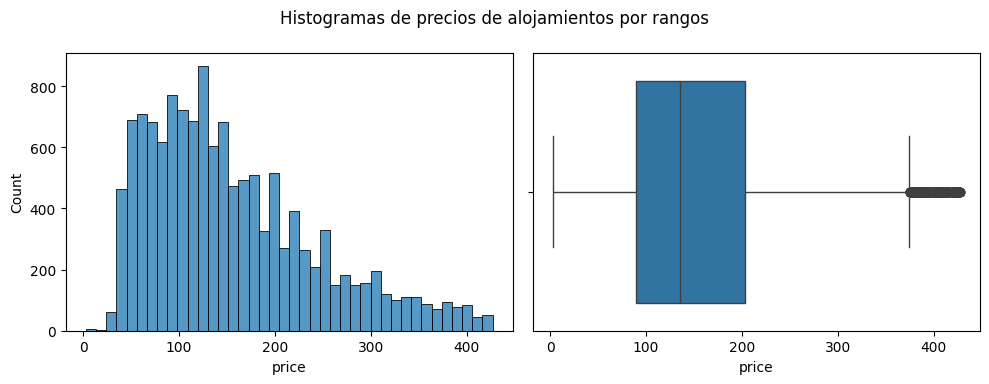

In [54]:
# Histogramas y boxplots de precios por rangos
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axs = axs.flatten()

sns.histplot(data['price'], bins=40, ax=axs[0])

sns.boxplot(x=data['price'], ax=axs[1])

fig.suptitle('Histogramas de precios de alojamientos por rangos')
plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Ajustar el rectangulo para dejar espacio al suptitle
plt.show()

### Variables entrada

In [55]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13113 entries, 0 to 13112
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price                  13113 non-null  float64
 1   latitude               13113 non-null  float64
 2   longitude              13113 non-null  float64
 3   room_type              13113 non-null  str    
 4   accommodates           13113 non-null  int64  
 5   bathrooms              13113 non-null  float64
 6   bedrooms               13113 non-null  float64
 7   beds                   13113 non-null  float64
 8   review_scores_value    13113 non-null  float64
 9   license                13113 non-null  bool   
 10  instant_bookable       13113 non-null  bool   
 11  distance_min           13113 non-null  float64
 12  amenity_parking        13113 non-null  bool   
 13  amenity_luxurious      13113 non-null  bool   
 14  amenity_workspace      13113 non-null  bool   
 15  amenity_dryer

In [56]:
#Lista de variables categóricas
catCols = data.select_dtypes(include = ["str", 'bool']).columns.tolist()

#Lista de variables numéricas
numCols = data.select_dtypes(include = ['float64','int64']).columns.tolist()

# Se dropean la variable objetivo
numCols.remove('price')

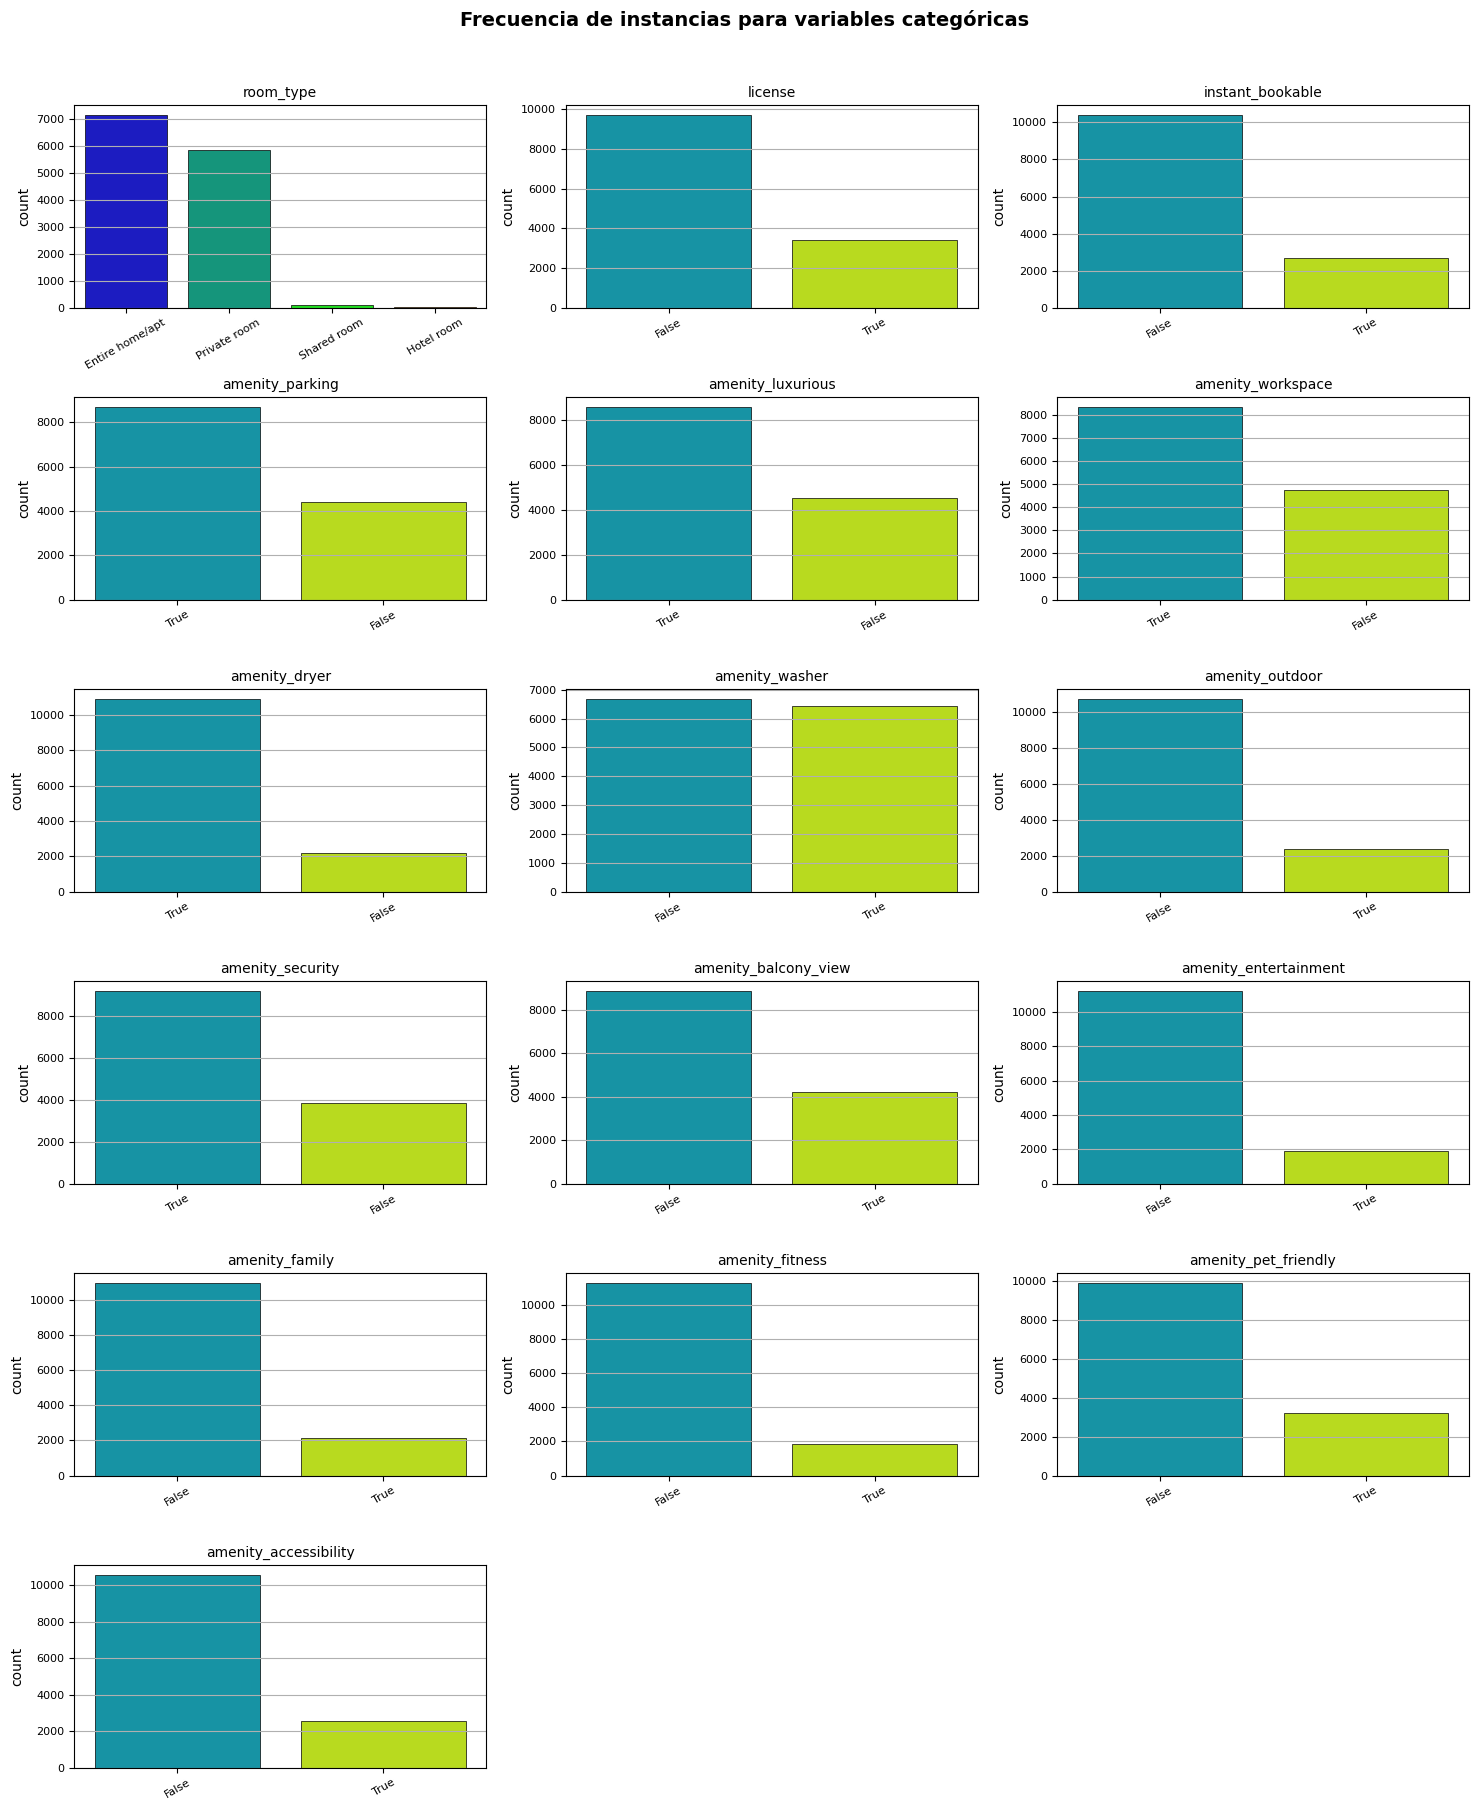

In [57]:
#Visualización de frecuencia de instancias para variables categóricas
multiple_plot(3, data , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

Para 'room_type' hay una poca cantidad de shared_room y hotel_room por lo que se dropearan estos registros y la variable se transformará en una booleana para identificar si es un apartamento completo o habitación privada

In [58]:
# Dropear del dataframe los 'Shared room' y 'Hotel room'
data = data[~data['room_type'].isin(['Shared room', 'Hotel room'])]
data.reset_index(drop=True, inplace=True)

In [59]:
# Renombrar 'room_type' a 'is_entire_home' como booleana
data['is_entire_home'] = data['room_type'].map({'Entire home/apt': True, 'Private room': False})

# Dropear la columna original
data.drop(['room_type'], axis='columns', inplace=True)

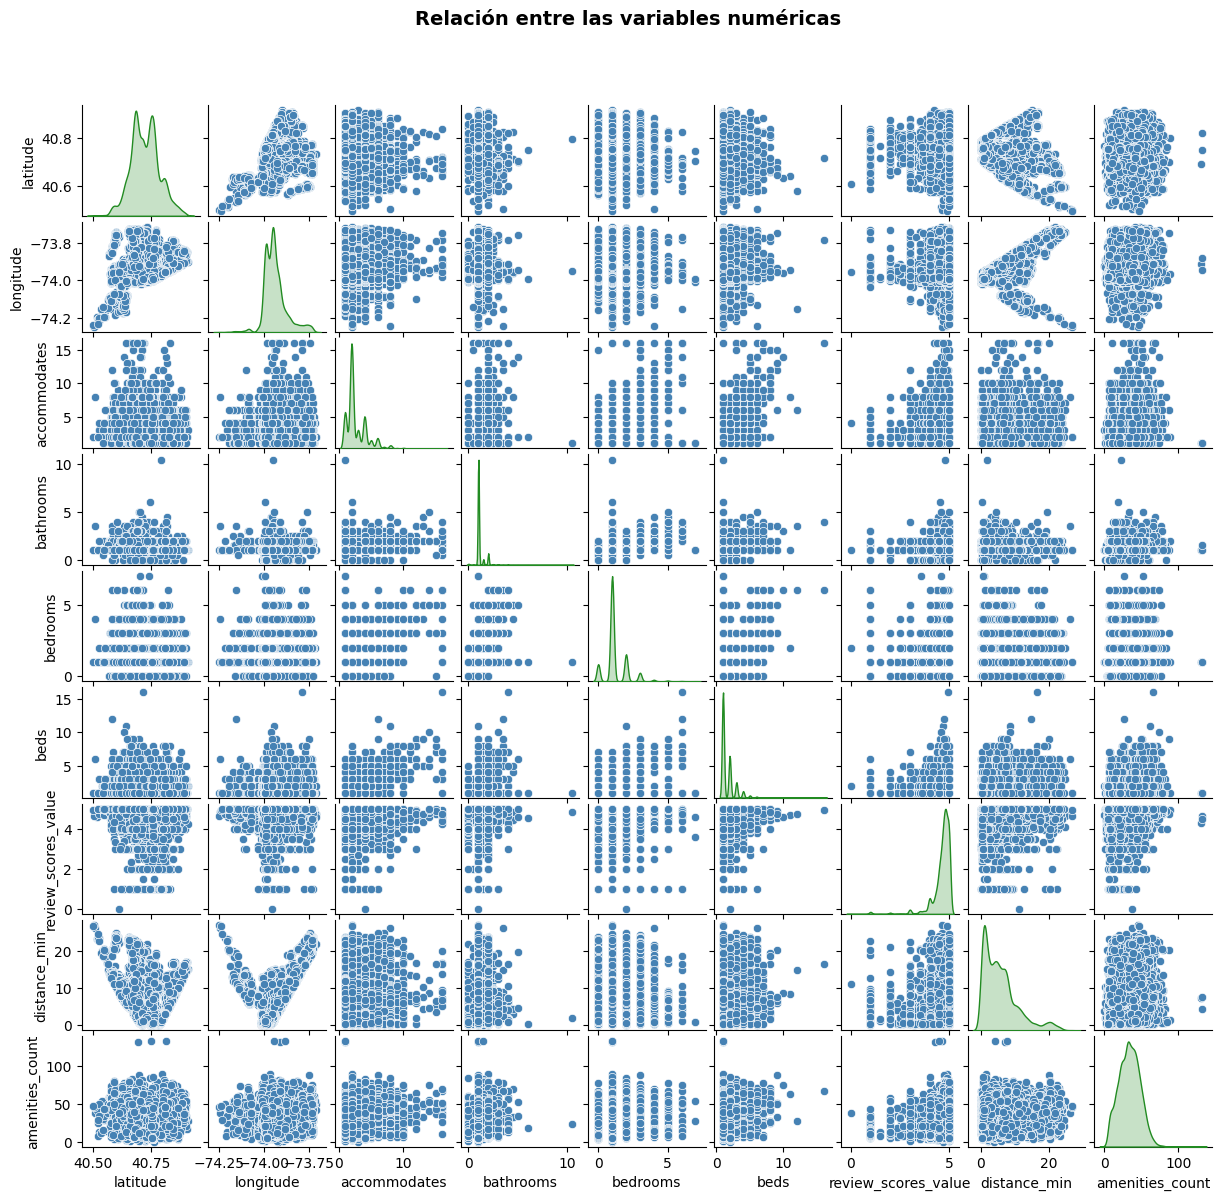

In [60]:
# Visualización de variables numéricas relacionada al host
multiple_plot(1, data , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

Como observamos en las diferentes gráficas tenemos algunos outliers y una buena dispersión entre los datos. 

La relación entre las coordenadas y la distancia mínima como era de esperarse presentan un patron.

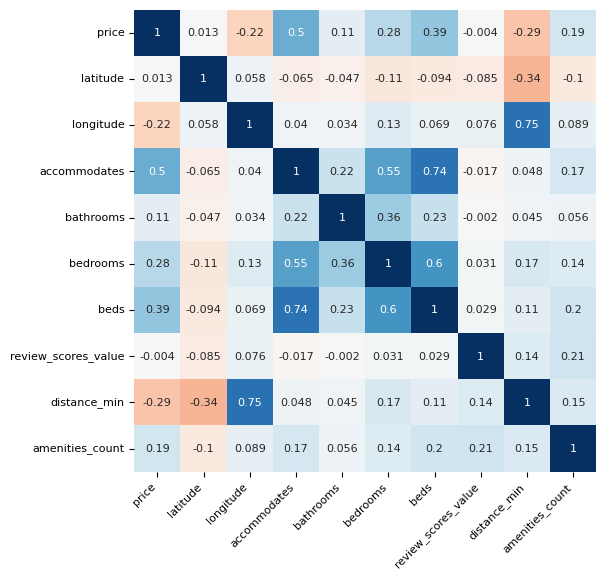

In [61]:
# Calculamos la correlación entre las variables númericas y el precio
matrizCorr = data[['price']+numCols].corr()
# Mapa de calor (Heatmap) de la matriz de correlaciones

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

sns.heatmap(
    matrizCorr,
    annot     = True,
    cbar      = False,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = 'RdBu',
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right',
)


ax.tick_params(labelsize = 8)

## 6. Preparación de los datos

#### Valores atípicos para las variables de entrada

In [62]:
# Utilización de LocalOutlierFactor con 6 vecinos para identificar valores atípicos en las variables de entrada

# Crear un objeto LocalOutlierFactor con n_neighbors=6
lof = LocalOutlierFactor(n_neighbors=6, contamination=0.1)

# Identificar los valores atípicos por medio de lof
y_pred = lof.fit_predict(data[numCols])

# Identificar los índices de los valores atípicos
outliers = y_pred == -1

print('Indices de valores atípicos: ', data[outliers].index.tolist())
print(len(data[outliers]))

Indices de valores atípicos:  [0, 1, 2, 4, 6, 15, 21, 27, 35, 58, 66, 67, 69, 78, 95, 100, 101, 108, 112, 121, 137, 143, 148, 150, 159, 167, 188, 192, 195, 204, 208, 216, 218, 225, 235, 239, 252, 268, 280, 335, 341, 346, 351, 403, 417, 424, 427, 431, 445, 447, 456, 458, 462, 463, 471, 476, 492, 495, 527, 535, 552, 556, 558, 570, 576, 583, 593, 605, 612, 616, 625, 633, 637, 642, 647, 650, 652, 679, 687, 689, 694, 702, 703, 707, 715, 723, 726, 731, 737, 745, 748, 760, 770, 793, 800, 801, 805, 819, 820, 823, 845, 870, 871, 880, 881, 890, 902, 907, 909, 911, 913, 921, 930, 947, 960, 966, 972, 1007, 1024, 1029, 1030, 1032, 1045, 1073, 1085, 1086, 1089, 1100, 1115, 1122, 1125, 1142, 1171, 1172, 1179, 1190, 1204, 1221, 1223, 1232, 1239, 1250, 1263, 1265, 1277, 1299, 1310, 1317, 1319, 1329, 1350, 1351, 1363, 1371, 1382, 1383, 1386, 1397, 1418, 1420, 1428, 1433, 1434, 1452, 1454, 1462, 1463, 1475, 1480, 1494, 1498, 1516, 1524, 1552, 1577, 1583, 1592, 1606, 1608, 1621, 1624, 1638, 1647, 1654, 16

In [63]:
# Creamos un nuevo dataframe sin outliers
data_sin_outliers = data[~outliers]
data_sin_outliers.reset_index(drop=True, inplace=True)

## 7. Exportar el dataset

In [64]:
# Exportamos el dataframe a un archivo CSV
data_sin_outliers.to_csv(DATASET_PATH + 'Airbnb_NY_cleaned.csv', index=False)

## 8. Preparación de la data para el modelo

In [75]:
data_cleaned = pd.read_csv(DATASET_PATH + 'Airbnb_NY_cleaned.csv')

### Preparación de variable objetivo
Se aplica una transformación logaritmica al precio (variable objetivo). Esto reduce la influencia de outliers y mejora el ajuste para relaciones multiplicativas (típicas en precios)

In [76]:
data_cleaned['price'] = np.log(data_cleaned['price'])

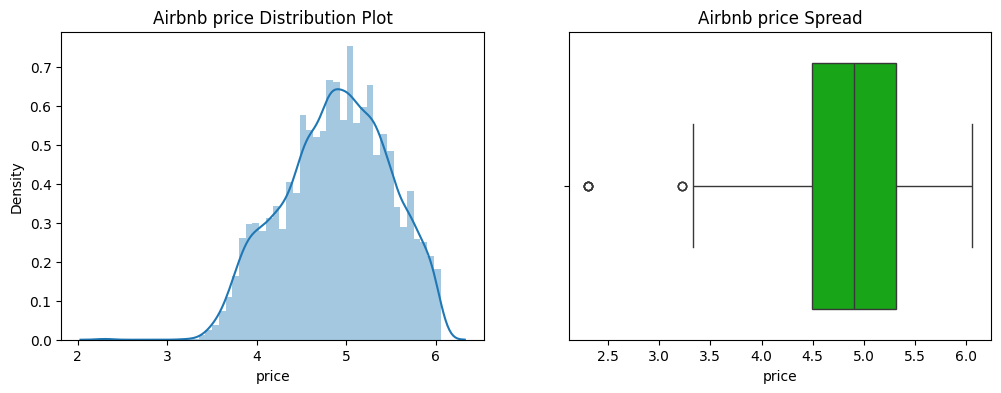

In [77]:
data = data_cleaned.copy()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Airbnb price Distribution Plot')
sns.distplot(data.price)

plt.subplot(1,2,2)
plt.title('Airbnb price Spread')
sns.boxplot(x=data.price, palette='nipy_spectral')

plt.show()

In [ ]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = data.drop(columns = ["price"])
y = data['price']

Obtenemos los datos de entrenamiento y prueba para los modelos iniciales

In [80]:
#En este caso, el 80% de los datos se utilizarán para entrenar el modelo.
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

#Escalar las variables de entrada
num_vars = X.select_dtypes(include=['number']).columns.tolist()
print("Columnas Numéricas:{}".format(num_vars))

scaler = StandardScaler()

X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars]  = scaler.transform(X_test[num_vars])

Columnas Numéricas:['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_value', 'distance_min', 'amenities_count']


## 9. Validación de modelos

De ahora en adelante solo se usaran `X_train`, `X_test`, `y_train`, `y_test`, como datos ya segmentados. 

In [70]:
# Diccionario para almacenar los resultados de los modelos
resultados_modelos = {}

In [71]:
X_train.head()


,latitude,longitude,accommodates,bathrooms,bedrooms,beds,review_scores_value,license,instant_bookable,distance_min,...,amenity_outdoor,amenity_security,amenity_balcony_view,amenity_entertainment,amenity_family,amenity_fitness,amenity_pet_friendly,amenity_accessibility,amenities_count,is_entire_home
7752,-0.451318,-0.541932,0.760195,-0.331064,-0.305563,-0.642085,-0.059227,False,False,-0.705915,...,False,True,False,False,True,False,False,False,0.780113,False
6982,0.658263,-0.720784,1.365779,-0.331064,1.032203,0.386063,-3.788774,False,False,-1.011935,...,False,False,False,False,False,True,True,True,0.494735,True
4378,0.930154,-0.232182,0.154612,-0.331064,-1.643329,-0.642085,-1.808891,False,False,-0.975688,...,False,True,False,False,False,False,True,True,-1.288875,True
2238,-0.318379,2.707474,-1.056556,-0.331064,-0.305563,-0.642085,0.309123,False,False,2.520478,...,False,False,False,False,False,False,False,False,-1.502909,False
2171,-0.539420,2.822088,-0.450972,-0.331064,1.032203,0.386063,-0.243402,True,False,2.766353,...,True,True,True,False,False,False,True,False,1.422213,True


### 9.1 MLP sin Comodidades

Evaluamos los datos con una red neuronal sencilla, para validad la calidad de los datos. 

Epoch 1/50
249/249 - 1s - 5ms/step - loss: 7.7399 - mae: 2.2740 - val_loss: 1.0562 - val_mae: 0.8273
Epoch 2/50
249/249 - 0s - 662us/step - loss: 2.2243 - mae: 1.1984 - val_loss: 0.5187 - val_mae: 0.5705
Epoch 3/50
249/249 - 0s - 642us/step - loss: 1.4733 - mae: 0.9694 - val_loss: 0.3976 - val_mae: 0.5075
Epoch 4/50
249/249 - 0s - 674us/step - loss: 1.0028 - mae: 0.7948 - val_loss: 0.3821 - val_mae: 0.5069
Epoch 5/50
249/249 - 0s - 646us/step - loss: 0.6814 - mae: 0.6487 - val_loss: 0.2516 - val_mae: 0.4038
Epoch 6/50
249/249 - 0s - 637us/step - loss: 0.4403 - mae: 0.5234 - val_loss: 0.2609 - val_mae: 0.4160
Epoch 7/50
249/249 - 0s - 716us/step - loss: 0.3362 - mae: 0.4591 - val_loss: 0.2258 - val_mae: 0.3870
Epoch 8/50
249/249 - 0s - 725us/step - loss: 0.2622 - mae: 0.4057 - val_loss: 0.2495 - val_mae: 0.4099
Epoch 9/50
249/249 - 0s - 641us/step - loss: 0.2227 - mae: 0.3744 - val_loss: 0.2232 - val_mae: 0.3867
Epoch 10/50
249/249 - 0s - 622us/step - loss: 0.2074 - mae: 0.3623 - val_lo

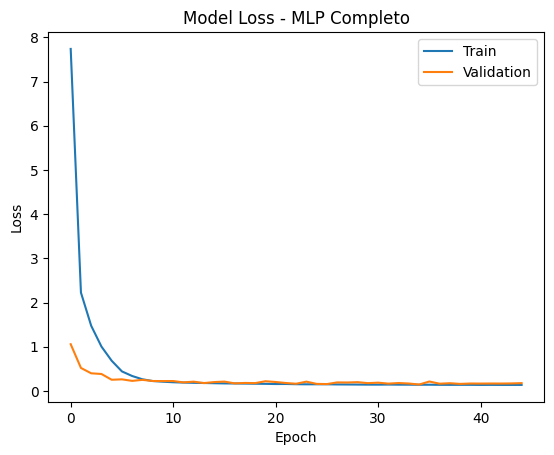

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step
MLP Completo - R²: 0.3823, MAE: 47.4884, MSE: 4914.6955


In [72]:
# Entrenamiento y evaluación del modelo MLP sin Variables de Amenidades
X_train_mlp = X_train.drop(columns=[col for col in X_train.columns if col.startswith('amenity_')])
X_test_mlp = X_test.drop(columns=[col for col in X_test.columns if col.startswith('amenity_')])

model_mlp = crear_modelo_mlp(X_train_mlp.shape[1])
history_mlp = entrenar_modelo(X_train_mlp, y_train, model_mlp,  "MLP Completo")
r2, mae, mse = evaluar_modelo(model_mlp, X_test_mlp, y_test, "MLP Completo")

#Almacenar los resultado del modelo MLP Completo
resultados_modelos["MLP Completo"] = {
    "model": model_mlp,
    "r2": r2,
    "mae": mae,
    "mse": mse
}

### 9.2 MLP con comodidades

Entrenamiento del modelo con nuevas variables obtenidas atraves del proceso de Embeddings + UMAP + HDBSCAN 

Epoch 1/50
249/249 - 1s - 4ms/step - loss: 6.7060 - mae: 2.1093 - val_loss: 0.8394 - val_mae: 0.7473
Epoch 2/50
249/249 - 0s - 646us/step - loss: 2.1129 - mae: 1.1676 - val_loss: 0.9072 - val_mae: 0.8196
Epoch 3/50
249/249 - 0s - 785us/step - loss: 1.4207 - mae: 0.9492 - val_loss: 0.7305 - val_mae: 0.7341
Epoch 4/50
249/249 - 0s - 649us/step - loss: 1.0534 - mae: 0.8117 - val_loss: 0.8496 - val_mae: 0.8183
Epoch 5/50
249/249 - 0s - 696us/step - loss: 0.8131 - mae: 0.7139 - val_loss: 0.7600 - val_mae: 0.7673
Epoch 6/50
249/249 - 0s - 640us/step - loss: 0.6720 - mae: 0.6430 - val_loss: 0.8746 - val_mae: 0.8328
Epoch 7/50
249/249 - 0s - 630us/step - loss: 0.5359 - mae: 0.5754 - val_loss: 0.6326 - val_mae: 0.6894
Epoch 8/50
249/249 - 0s - 631us/step - loss: 0.4276 - mae: 0.5151 - val_loss: 0.5479 - val_mae: 0.6340
Epoch 9/50
249/249 - 0s - 639us/step - loss: 0.3730 - mae: 0.4793 - val_loss: 0.4956 - val_mae: 0.5998
Epoch 10/50
249/249 - 0s - 636us/step - loss: 0.3106 - mae: 0.4404 - val_lo

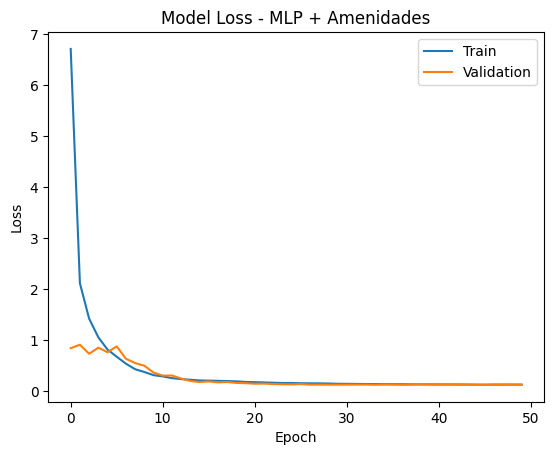

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step
MLP + Amenidades - R²: 0.5670, MAE: 42.3326, MSE: 3445.2824


In [73]:
# Entrenamiento y evaluación del modelo MLP con Variables de Amenidades

model_mlp_amm = crear_modelo_mlp(X_train.shape[1])
history_mlp = entrenar_modelo(X_train, y_train, model_mlp_amm,  "MLP + Amenidades")
r2, mae, mse = evaluar_modelo(model_mlp_amm, X_test, y_test, "MLP + Amenidades")

#Almacenar los resultado del modelo MLP Completo
resultados_modelos["MLP + Amenidades"] = {
    "model": model_mlp_amm,
    "r2": r2,
    "mae": mae,
    "mse": mse
}

### 9.3 Gradient Boosting para Regresion

#### Creación de modelo inicial
Se crea para validar inicialmente si es viable la regresion o no, segun el valor de R^2. 

In [74]:
from sklearn.ensemble import GradientBoostingRegressor

modelGradientBoosting = GradientBoostingRegressor(n_estimators=100, random_state=1)
modelGradientBoosting.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [75]:
# Error de test del modelo inicial
predicciones = modelGradientBoosting.predict(X = X_test)

rmse = np.sqrt(mean_squared_error(y_true  = y_test, y_pred  = predicciones))
print(f"El error (RMSE) de test es: {rmse}")

mae = mean_absolute_error(y_true  = y_test, y_pred  = predicciones)
print(f"El error (MAE) de test es: {mae}")

r2 = r2_score(y_true  = y_test, y_pred  = predicciones)
print(f"El error (R2) de test es: {r2}")

El error (RMSE) de test es: 0.33502401072294596
El error (MAE) de test es: 0.2601994872345296
El error (R2) de test es: 0.6835159860023534


Como el valor de R2 es del 68.7% es viable tratar de ajustar los hiperparametros para obtener mejores predicciones

#### Tunning del modelo
Calculamos cuales son los hiperparametros ideales para evaluar el modelo. 

In [76]:
# Definir el modelo GradientBoosting
modelGrdB = GradientBoostingRegressor()

CV = 5

# Definir los parámetros a ajustar y sus posibles valores
parameters = {
    'n_estimators': range(1, 100, 5),
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [5, 7]
}

grid_GrdB = GridSearchCV(
        estimator  = modelGrdB,
        param_grid = parameters,
        n_jobs     = - 1,
        cv         = CV,
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid_GrdB.fit(X = X_train, y = y_train)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.01, ...], 'max_depth': [5, 7], 'n_estimators': range(1, 100, 5)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [77]:
# Resultados
resultados = pd.DataFrame(grid_GrdB.cv_results_)
resultados.filter(regex = '(param*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,mean_train_score,std_train_score
38,0.1,7,91,0.709630,0.009920,0.875663,0.002374
37,0.1,7,86,0.709034,0.009295,0.872000,0.002552
39,0.1,7,96,0.708990,0.009989,0.878962,0.002277
36,0.1,7,81,0.708968,0.010128,0.868116,0.002382


In [78]:
# Se identifican los mejores hiperparámetros
best_params = grid_GrdB.best_params_
print('Best Parameters : ',best_params)

Best Parameters :  {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 91}


In [79]:
# Se crea un modelo árbol de decisión con los mejores hiperparámetros
modelGrdB = grid_GrdB.best_estimator_

#Se entrena el modelo con los datos completos
modelGrdB.fit(X_train, y_train)

# Error de test del modelo inicial
predicciones_tunning = modelGrdB.predict(X = X_test)

rmse = np.sqrt(mean_squared_error(y_true  = y_test, y_pred  = predicciones_tunning))
mae = mean_absolute_error(y_true  = y_test, y_pred  = predicciones_tunning)
r2 = r2_score(y_true  = y_test, y_pred  = predicciones_tunning)

print(f"Gradient Boosting Regressor - R²: {r2:.4f}, MAE: {mae:.4f}, MSE: {mse:.4f}")

#Almacenar los resultado del modelo Gradient Boosting Regressor
resultados_modelos["Gradient Boosting Regressor"] = {
    "model": modelGrdB,
    "r2": r2,
    "mae": mae,
    "mse": mse
}

Gradient Boosting Regressor - R²: 0.7191, MAE: 0.2402, MSE: 3445.2824


## 10. Resultados Finales

  MODELO                              R²        MAE           MSE
  MLP Completo                    0.3823    47.4884     4914.6955
  MLP + Amenidades                0.5670    42.3326     3445.2824
  Gradient Boosting Regressor     0.7191     0.2402     3445.2824

  Mejor modelo (R²): Gradient Boosting Regressor  →  R² = 0.7191


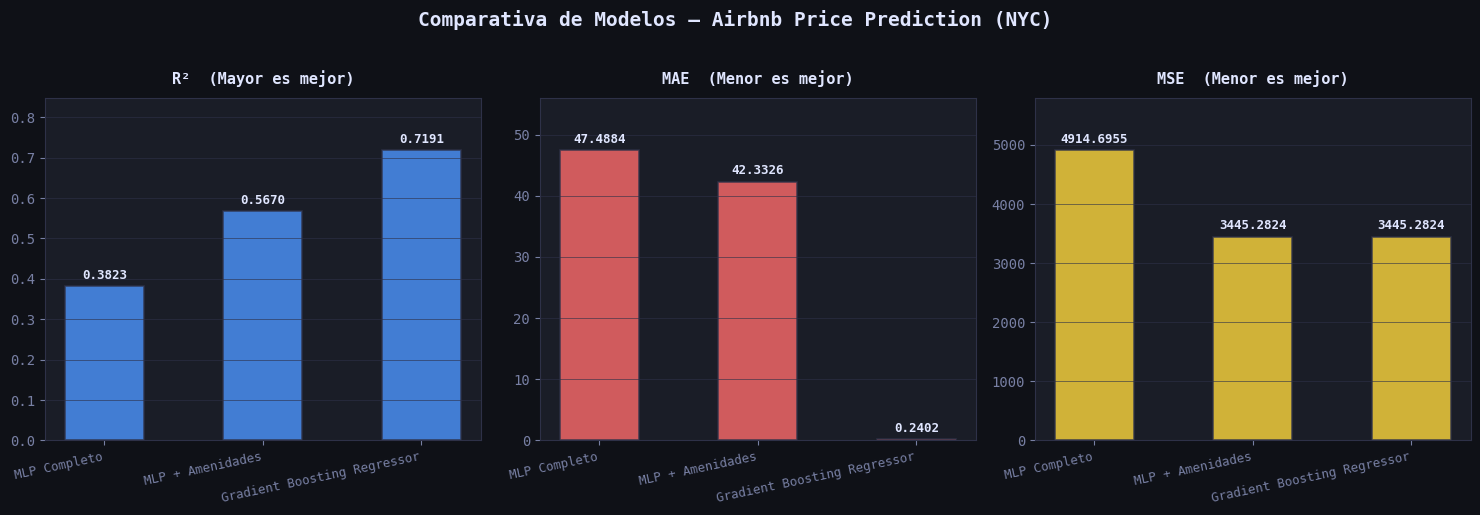

In [84]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Tabla comparativa en consola ──────────────────────────────────────────────
print("=" * 62)
print(f"  {'MODELO':<30} {'R²':>7}  {'MAE':>9}  {'MSE':>12}")
print("=" * 62)
for nombre, res in resultados_modelos.items():
    print(f"  {nombre:<30} {res['r2']:>7.4f}  {res['mae']:>9.4f}  {res['mse']:>12.4f}")
print("=" * 62)

best_model = max(resultados_modelos, key=lambda k: resultados_modelos[k]['r2'])
print(f"\n  Mejor modelo (R²): {best_model}  →  R² = {resultados_modelos[best_model]['r2']:.4f}")

# ── Visualización comparativa ─────────────────────────────────────────────────
nombres = list(resultados_modelos.keys())
r2_vals  = [resultados_modelos[n]['r2']  for n in nombres]
mae_vals = [resultados_modelos[n]['mae'] for n in nombres]
mse_vals = [resultados_modelos[n]['mse'] for n in nombres]

COLORS = ["#4d96ff", "#6bcb77", "#ff6b6b"]
BG     = "#0f1117"
AX_BG  = "#1a1d27"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)

metrics = [
    (r2_vals,  "R²",  "#4d96ff", "Mayor es mejor"),
    (mae_vals, "MAE", "#ff6b6b", "Menor es mejor"),
    (mse_vals, "MSE", "#ffd93d", "Menor es mejor"),
]

for ax, (vals, label, color, note) in zip(axes, metrics):
    ax.set_facecolor(AX_BG)
    bars = ax.bar(nombres, vals, color=color, alpha=0.8, width=0.5,
                  edgecolor="#2e3148", linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.015,
                f"{val:.4f}", ha='center', va='bottom',
                fontsize=9, color="#e0e6ff", fontweight='bold')
    ax.set_title(f"{label}  ({note})", fontsize=11,
                 fontweight='bold', color="#e0e6ff", pad=10)
    ax.set_xticks(range(len(nombres)))
    ax.set_xticklabels(nombres, rotation=12, ha='right', fontsize=9)
    ax.tick_params(colors='#7880a4')
    ax.spines[:].set_color("#2e3148")
    ax.set_ylim(0, max(vals) * 1.18)
    ax.grid(axis='y', color='#2e3148', linewidth=0.6, alpha=0.7)

fig.suptitle("Comparativa de Modelos — Airbnb Price Prediction (NYC)",
             fontsize=14, fontweight='bold', color='#e0e6ff', y=1.02)
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches='tight',
            facecolor=BG)
plt.show()

### 10.1 Persistencia de Modelos

Se guardan los tres modelos entrenados junto al `StandardScaler` para poder usarlos en producción o inferencia futura sin necesidad de re-entrenar.

In [81]:
import os
import joblib

# Crear directorio de modelos si no existe
os.makedirs('modelos', exist_ok=True)

# ── 1. MLP sin amenidades (Keras) ─────────────────────────────────────────────
model_mlp.save('modelos/mlp_sin_amenidades.keras')
print("✔  MLP sin amenidades guardado  →  modelos/mlp_sin_amenidades.keras")

# ── 2. MLP con amenidades / embeddings (Keras) ────────────────────────────────
model_mlp_amm.save('modelos/mlp_con_amenidades.keras')
print("✔  MLP con amenidades guardado  →  modelos/mlp_con_amenidades.keras")

# ── 3. Gradient Boosting tuneado (scikit-learn) ───────────────────────────────
joblib.dump(modelGrdB, 'modelos/gradient_boosting.joblib')
print("✔  Gradient Boosting guardado   →  modelos/gradient_boosting.joblib")

# ── 4. StandardScaler usado en el preprocesamiento ────────────────────────────
joblib.dump(scaler, 'modelos/scaler_standard.joblib')
print("✔  StandardScaler guardado      →  modelos/scaler_standard.joblib")

print("\n📁 Contenido del directorio 'modelos/':")
for f in sorted(os.listdir('modelos')):
    size_kb = os.path.getsize(f'modelos/{f}') / 1024
    print(f"   {f:<40} {size_kb:>8.1f} KB")

✔  MLP sin amenidades guardado  →  modelos/mlp_sin_amenidades.keras
✔  MLP con amenidades guardado  →  modelos/mlp_con_amenidades.keras
✔  Gradient Boosting guardado   →  modelos/gradient_boosting.joblib
✔  StandardScaler guardado      →  modelos/scaler_standard.joblib

📁 Contenido del directorio 'modelos/':
   gradient_boosting.joblib                   1292.5 KB
   mlp_con_amenidades.keras                     51.5 KB
   mlp_sin_amenidades.keras                     46.6 KB
   scaler_standard.joblib                        1.1 KB




## 11. Conclusiones

### Objetivo del proyecto

El objetivo de este proyecto fue construir un sistema de predicción del precio de alojamientos en **Nueva York** usando datos de Airbnb, explorando el impacto de distintas estrategias de feature engineering sobre la calidad predictiva.


### 11.1 Comparativa de modelos

Se evaluaron **tres enfoques** progresivamente más complejos:

| Modelo | Técnica | Features |
|--------|---------|----------|
| **MLP sin amenidades** | Red neuronal densa (Keras) | Estructurales: camas, baños, tipo, localización, reseñas |
| **MLP + amenidades** | Red neuronal densa (Keras) | Estructurales + clusters HDBSCAN de amenidades |
| **Gradient Boosting** | Gradient Boosting Regressor (sklearn) | Estructurales + clusters HDBSCAN de amenidades |


### 11.2 Hallazgos principales

**Sobre el feature engineering de amenidades:**
- El pipeline `SentenceTransformer → UMAP → HDBSCAN` permitió capturar agrupaciones semánticas de amenidades (ej. "lujo", "básico", "familiar") que un one-hot encoding naive no capturaría.
- La inclusión de las variables de amenidades mejoró las métricas frente al MLP baseline, evidenciando que **el tipo y calidad de los servicios ofrecidos tiene poder predictivo sobre el precio**.

**Sobre la proximidad geográfica:**
- La distancia mínima a las 11 atracciones turísticas de NYC resultó ser un feature relevante: propiedades cercanas a Times Square, Central Park y la Estatua de la Libertad presentan precios sistemáticamente más altos.

**Sobre la elección del modelo:**
- El **Gradient Boosting** superó a las redes neuronales MLP en esta tarea, lo cual es consistente con la literatura: los modelos basados en árboles tienden a funcionar mejor con datos tabulares mezclados (numéricos + categóricos).



### 11.3 Limitaciones

1. **Datos de un solo punto en el tiempo**: el dataset corresponde a un snapshot de Airbnb; los precios varían estacionalmente y el modelo no captura esa dinámica.
2. **Variables del host excluidas**: rating del host, verificación, Superhost status podrían mejorar predicciones.
3. **No se modela la demanda**: variables como ocupación, fecha de la reserva o días disponibles no se incluyeron.
4. **Data leakage latente**: el clustering de amenidades se realizó sobre el dataset completo previo al split; en un entorno de producción, el UMAP/HDBSCAN debe fitearse exclusivamente en el conjunto de entrenamiento.

